# Hyper AI Fund – Customer Classification Report
Multi-class customer classification model built using machine learning
to predict customer interest in an AI-focused investment fund.

**Author:** Gayathri Gigeev  
**Date:** July 2025  

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model training and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Feature selection and modelling pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline


## Step 1: Load and Preview the Customer Dataset
We load the provided dataset of 2000 customers to begin our analysis and modelling process.


In [4]:
# Load customer dataset
customer_data = pd.read_csv("ICM520_2024_2025_Report_PartA_DataSet_2000Rows.csv")

# Preview first few rows
customer_data.head()

,FEAT_0,FEAT_1,FEAT_2,FEAT_3,FEAT_4,FEAT_5,FEAT_6,FEAT_7,FEAT_8,FEAT_9,FEAT_10,FEAT_11,FEAT_12,FEAT_13,FEAT_14,FEAT_15,FEAT_16,FEAT_17,CATEGORY
0,0.04,JOB_B,2,1,-0.04,8,9,0.68,0.84,6.0,5,0.9,0.3,-0.3,8,CITY_A,0.21,0.14,1
1,0.58,JOB_B,1,3,-0.58,7,10,0.14,0.04,4.0,4,0.7,0.0,0.0,1,CITY_A,0.01,0.13,1
2,0.57,JOB_B,0,4,-0.57,7,1,0.25,0.15,10.0,1,0.0,0.8,-0.8,5,CITY_A,0.01,0.94,0
3,0.02,JOB_A,1,2,-0.02,3,2,0.84,0.31,7.0,6,0.0,0.4,-0.4,1,CITY_A,0.14,0.50,1
4,0.01,JOB_A,1,4,-0.01,0,0,0.04,0.71,7.0,4,0.7,0.3,-0.3,3,CITY_A,0.55,0.18,0


## Step 2: Understand the Structure and Summary of the Dataset
Check data types, identify numeric and categorical features, and review basic statistics for each column.


In [7]:
# View dataset structure
customer_data.info()

# Summary statistics for numeric columns
customer_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FEAT_0    2000 non-null   float64
 1   FEAT_1    2000 non-null   object 
 2   FEAT_2    2000 non-null   int64  
 3   FEAT_3    2000 non-null   int64  
 4   FEAT_4    2000 non-null   float64
 5   FEAT_5    2000 non-null   int64  
 6   FEAT_6    2000 non-null   int64  
 7   FEAT_7    2000 non-null   float64
 8   FEAT_8    2000 non-null   float64
 9   FEAT_9    1816 non-null   float64
 10  FEAT_10   2000 non-null   int64  
 11  FEAT_11   2000 non-null   float64
 12  FEAT_12   2000 non-null   float64
 13  FEAT_13   2000 non-null   float64
 14  FEAT_14   2000 non-null   int64  
 15  FEAT_15   2000 non-null   object 
 16  FEAT_16   2000 non-null   float64
 17  FEAT_17   2000 non-null   float64
 18  CATEGORY  2000 non-null   int64  
dtypes: float64(10), int64(7), object(2)
memory usage: 297.0+ KB


,FEAT_0,FEAT_2,FEAT_3,FEAT_4,FEAT_5,FEAT_6,FEAT_7,FEAT_8,FEAT_9,FEAT_10,FEAT_11,FEAT_12,FEAT_13,FEAT_14,FEAT_16,FEAT_17,CATEGORY
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,1816.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.00000
mean,0.333960,1.005000,2.992000,-0.333960,40.252000,5.082500,0.33655,0.333735,4.997797,5.035000,0.495300,0.501100,-0.501100,4.901500,0.33902,0.328260,1.23350
std,0.303743,0.696576,1.216008,0.303743,184.200946,3.167919,0.30174,0.298583,3.216006,3.129964,0.287922,0.293891,0.293891,3.125009,0.30083,0.299766,1.02494
min,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.00000,0.000000,0.00000
25%,0.050000,1.000000,2.000000,-0.580000,2.000000,2.000000,0.06000,0.060000,2.000000,2.000000,0.300000,0.200000,-0.700000,2.000000,0.07000,0.060000,0.00000
50%,0.250000,1.000000,3.000000,-0.250000,5.000000,5.000000,0.25000,0.260000,5.000000,5.000000,0.500000,0.500000,-0.500000,5.000000,0.26000,0.240000,1.00000
75%,0.580000,1.000000,4.000000,-0.050000,8.000000,8.000000,0.57000,0.560000,8.000000,8.000000,0.700000,0.700000,-0.200000,8.000000,0.57000,0.542500,2.00000
max,1.000000,2.000000,5.000000,0.000000,1000.000000,10.000000,1.00000,1.000000,10.000000,10.000000,1.000000,1.000000,0.000000,10.000000,1.00000,1.000000,3.00000


## Step 3: Explore Target Variable and Identify Missing Data
Analyze the distribution of the target variable (`CATEGORY`) and detect any missing values that need to be handled.

C:\Users\gayat\AppData\Local\Temp\ipykernel_18620\744868046.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='pastel')


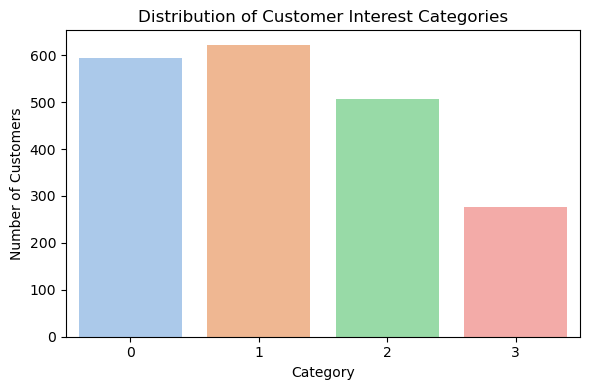

FEAT_9    184
dtype: int64

In [10]:
# Count the number of customers in each category
category_counts = customer_data['CATEGORY'].value_counts().sort_index()

# Plot the category distribution
plt.figure(figsize=(6,4))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='pastel')
plt.title("Distribution of Customer Interest Categories")
plt.xlabel("Category")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# Check for missing values
missing_values = customer_data.isnull().sum()
missing_values[missing_values > 0]


## Step 4: Data Cleaning and Preprocessing
Fill missing values, encode categorical variables, scale features, and split the data into training and test sets.

In [12]:
# 1. Make a copy of the original dataset
data = customer_data.copy()

# 2. Fill missing values in FEAT_9 with the mean (safe way to avoid warning)
data['FEAT_9'] = data['FEAT_9'].fillna(data['FEAT_9'].mean())

# 3. Encode the text features: FEAT_1 (job type) and FEAT_15 (city)
label_enc1 = LabelEncoder()
label_enc2 = LabelEncoder()
data['FEAT_1'] = label_enc1.fit_transform(data['FEAT_1'])  # e.g. JOB_A → 0, JOB_B → 1
data['FEAT_15'] = label_enc2.fit_transform(data['FEAT_15'])  # e.g. CITY_A → 0, CITY_B → 1

# 4. Separate features and target
X = data.drop('CATEGORY', axis=1)
y = data['CATEGORY']

# 5. Scale all features to standardize the values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Split into training and testing sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Check the dimensions of the splits
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1400, 18), (600, 18), (1400,), (600,))

## Step 5: Train and Evaluate Logistic Regression Model
Use Logistic Regression as a baseline model to classify customers into interest categories.

In [16]:
# 1. Create the Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

# 2. Train the model using the training data
logreg_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = logreg_model.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Show the results
print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.64

Confusion Matrix:
[[131  45   2   0]
 [ 42 103  41   1]
 [  0  40  88  24]
 [  0   2  20  61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       178
           1       0.54      0.55      0.55       187
           2       0.58      0.58      0.58       152
           3       0.71      0.73      0.72        83

    accuracy                           0.64       600
   macro avg       0.65      0.65      0.65       600
weighted avg       0.64      0.64      0.64       600



## Step 6: Train and Evaluate K-Nearest Neighbours Model  
Apply the K-Nearest Neighbours (KNN) algorithm to classify customer interest categories and compare its performance with previously tested models.

In [19]:
# Cell X: K-Nearest Neighbours Classification



# 1. Initialize the KNN model (here k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train on the training set
knn.fit(X_train, y_train)

# 3. Predict on the test set
y_knn = knn.predict(X_test)

# 4. Evaluate performance
knn_acc    = accuracy_score(y_test, y_knn)
knn_cm     = confusion_matrix(y_test, y_knn)
knn_report = classification_report(y_test, y_knn)

print(f"KNN Accuracy: {knn_acc:.2f}\n")
print("Confusion Matrix:")
print(knn_cm, "\n")
print("Classification Report:")
print(knn_report)


KNN Accuracy: 0.52

Confusion Matrix:
[[131  42   4   1]
 [ 72  88  24   3]
 [ 29  49  65   9]
 [  4  16  34  29]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.74      0.63       178
           1       0.45      0.47      0.46       187
           2       0.51      0.43      0.47       152
           3       0.69      0.35      0.46        83

    accuracy                           0.52       600
   macro avg       0.55      0.50      0.51       600
weighted avg       0.53      0.52      0.51       600



## Step 7: Train and Evaluate Random Forest Model
Use a Random Forest Classifier to capture more complex patterns in the data and compare its performance to the logistic regression baseline.


In [22]:
# 1. Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred_rf = rf_model.predict(X_test)

# 3. Evaluate performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

# Display results
print(f"Accuracy: {accuracy_rf:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)
print("\nClassification Report:")
print(class_report_rf)


Accuracy: 0.79

Confusion Matrix:
[[152  26   0   0]
 [ 23 147  17   0]
 [  0  24 118  10]
 [  0   0  25  58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       178
           1       0.75      0.79      0.77       187
           2       0.74      0.78      0.76       152
           3       0.85      0.70      0.77        83

    accuracy                           0.79       600
   macro avg       0.80      0.78      0.79       600
weighted avg       0.80      0.79      0.79       600



## Step 8: Feature Importance from Random Forest
Visualise which features contributed most to the Random Forest model's predictions.


C:\Users\gayat\AppData\Local\Temp\ipykernel_18620\3097959269.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


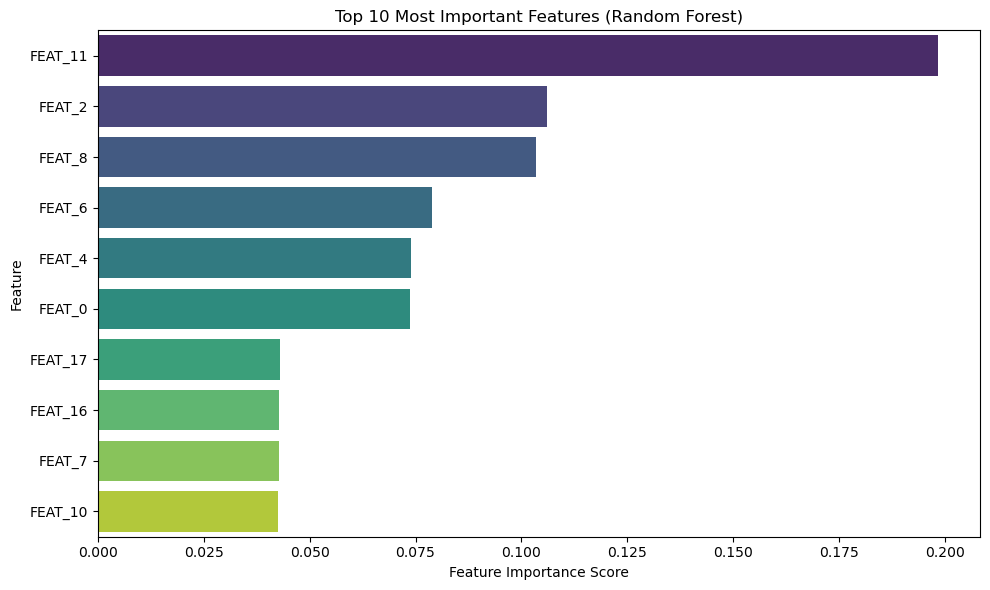

,Feature,Importance
11,FEAT_11,0.198311
2,FEAT_2,0.105972
8,FEAT_8,0.103375
6,FEAT_6,0.078839
4,FEAT_4,0.074013
0,FEAT_0,0.073648
17,FEAT_17,0.043106
16,FEAT_16,0.042788
7,FEAT_7,0.042717
10,FEAT_10,0.042569


In [24]:
# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# Match them to the feature names
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Optionally display the table
feature_importance_df.head(10)


## Step 9: Feature Selection using SelectKBest
Determine the minimum number of features required to achieve at least 70% model accuracy using mutual information-based selection.


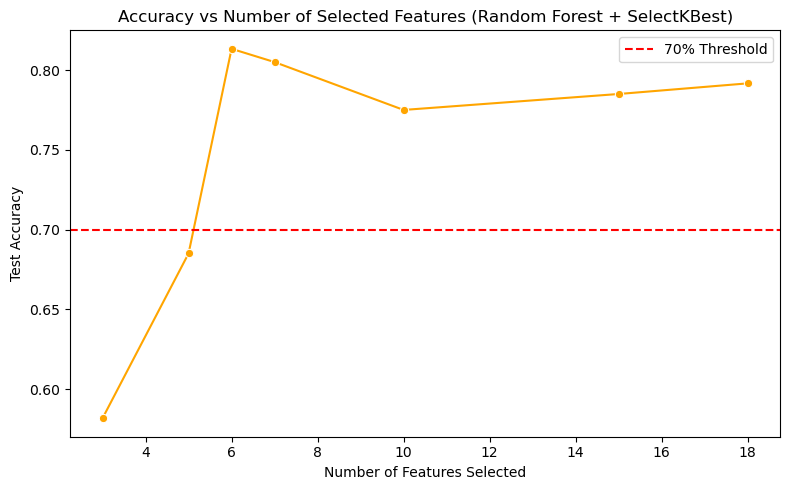

,Num_Features,Accuracy
0,3,0.581667
1,5,0.685000
2,6,0.813333
3,7,0.805000
4,10,0.775000
5,15,0.785000
6,18,0.791667


In [27]:
 # Try different numbers of features and store results
from functools import partial

k_values = [3, 5, 6 ,7, 10, 15, 18]
results = []

fixed_mi = partial(mutual_info_classif, random_state=42)

for k in k_values:
    # 1. Select top k features using mutual information
    selector = SelectKBest(score_func=fixed_mi, k=k)
    
    # 2. Create pipeline: feature selection + Random Forest model
    pipeline = Pipeline([
        ('select', selector),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    # 3. Fit the pipeline on training data
    pipeline.fit(X_train, y_train)
    
    # 4. Evaluate on test data
    acc = pipeline.score(X_test, y_test)
    results.append((k, acc))

# Convert results to DataFrame
kbest_results_df = pd.DataFrame(results, columns=['Num_Features', 'Accuracy'])

# Plot results
plt.figure(figsize=(8, 5))
sns.lineplot(data=kbest_results_df, x='Num_Features', y='Accuracy', marker='o', color='orange')
plt.axhline(0.70, color='red', linestyle='--', label='70% Threshold')
plt.title("Accuracy vs Number of Selected Features (Random Forest + SelectKBest)")
plt.xlabel("Number of Features Selected")
plt.ylabel("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Display results
kbest_results_df

In [29]:
# Get boolean mask or indices of selected features
selector = SelectKBest(score_func=fixed_mi, k=6)
selector.fit(X_train, y_train)

# Get indices of selected features
selected_indices = selector.get_support(indices=True)

# Print feature names
selected_features = X.columns[selected_indices]
print("Top 6 selected features:")
print(selected_features.tolist())
final_ftrs = selected_features.tolist()
final_ftrs

Top 6 selected features:
['FEAT_0', 'FEAT_2', 'FEAT_4', 'FEAT_6', 'FEAT_8', 'FEAT_11']


['FEAT_0', 'FEAT_2', 'FEAT_4', 'FEAT_6', 'FEAT_8', 'FEAT_11']

## Step 10: Final Random Forest Model Using Top 6 Selected Features  
Retrain the Random Forest model using the final 6 most informative features to evaluate whether a simpler, faster model can retain high prediction accuracy.

In [31]:
# 1. Make a copy of the original dataset
data = customer_data.copy()
final_ftrs.append('CATEGORY')

data2 = data[final_ftrs]
# 4. Separate features and target
X = data2.drop('CATEGORY', axis=1)
y = data2['CATEGORY']

# 5. Scale all features to standardize the values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Split into training and testing sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Check the dimensions of the splits
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1400, 6), (600, 6), (1400,), (600,))

In [32]:
# 1. Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred_rf = rf_model.predict(X_test)

# 3. Evaluate performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

# Display results
print(f"Accuracy: {accuracy_rf:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)
print("\nClassification Report:")
print(class_report_rf)


Accuracy: 0.81

Confusion Matrix:
[[151  27   0   0]
 [ 18 148  21   0]
 [  0  22 118  12]
 [  0   0  12  71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       178
           1       0.75      0.79      0.77       187
           2       0.78      0.78      0.78       152
           3       0.86      0.86      0.86        83

    accuracy                           0.81       600
   macro avg       0.82      0.82      0.82       600
weighted avg       0.82      0.81      0.81       600

